In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/food-delivery-time-prediction-case-study/Food Delivery Time Prediction Case Study.xlsx


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:

df=pd.read_excel('/kaggle/input/food-delivery-time-prediction-case-study/Food Delivery Time Prediction Case Study.xlsx')

In [4]:
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30
...,...,...,...,...,...,...,...,...,...,...,...
45588,7C09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,32
45589,D641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,36
45590,4F8D,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,16
45591,5EEE,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,26


In [5]:
df['ID'].value_counts()

ID
7000    4
6000    4
9000    4
700     4
900     3
       ..
2947    1
4102    1
C3F1    1
5DB7    1
5FB2    1
Name: count, Length: 45355, dtype: int64

### ID is a sparse distribution of rider id's. I don't think so I will be using it as a feature because we need to predict time also for new riders.

In [6]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Type_of_order                  0
Type_of_vehicle                0
Time_taken(min)                0
dtype: int64

# Basic EDA and feature engineering 

In [7]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)'],
      dtype='object')

In [8]:
x=df['Delivery_person_Age']
y=df['Time_taken(min)']

Text(0.5, 1.0, 'Relationship between age and delivery time')

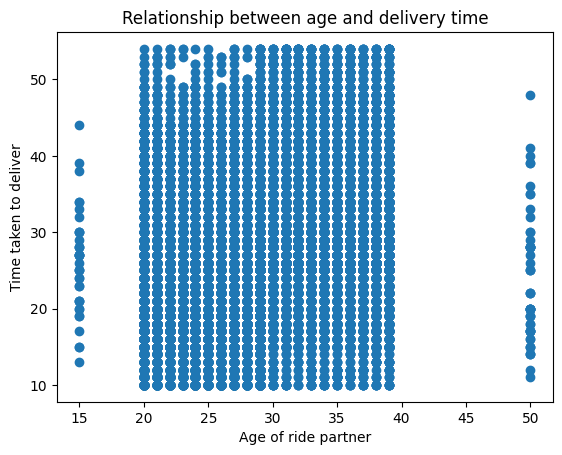

In [9]:
plt.scatter(x,y) 
plt.xlabel('Age of ride partner')
plt.ylabel('Time taken to deliver')
plt.title('Relationship between age and delivery time')


### There is not much clear relation between age of ride partner and delivery time.

In [10]:
x=df['Delivery_person_Ratings']
y=df['Time_taken(min)']

Text(0.5, 1.0, 'Relationship between rating and delivery time')

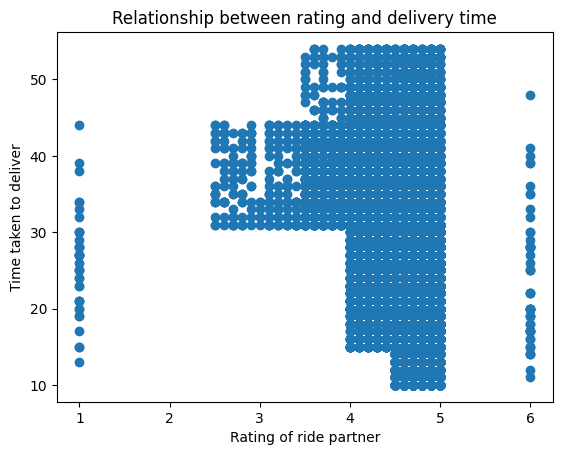

In [11]:
plt.scatter(x,y) 
plt.xlabel('Rating of ride partner')
plt.ylabel('Time taken to deliver')
plt.title('Relationship between rating and delivery time')

In [12]:
# create a feature of age*rating and age/rating. 
df['age-rating-1']=df['Delivery_person_Age']*df['Delivery_person_Ratings']
df['age-rating-2']=df['Delivery_person_Age']/df['Delivery_person_Ratings']

In [13]:
x1=df['age-rating-1']
x2=df['age-rating-2']


Text(0.5, 1.0, 'Relationship between age-rating and delivery time')

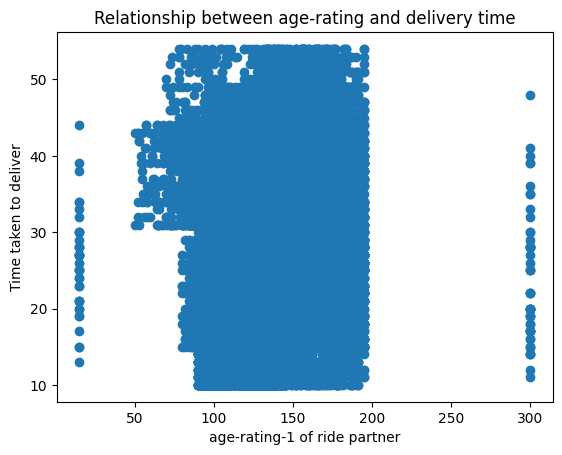

In [14]:
plt.scatter(x1,y) 
plt.xlabel('age-rating-1 of ride partner')
plt.ylabel('Time taken to deliver')
plt.title('Relationship between age-rating and delivery time')

Text(0.5, 1.0, 'Relationship between age-rating-2 and delivery time')

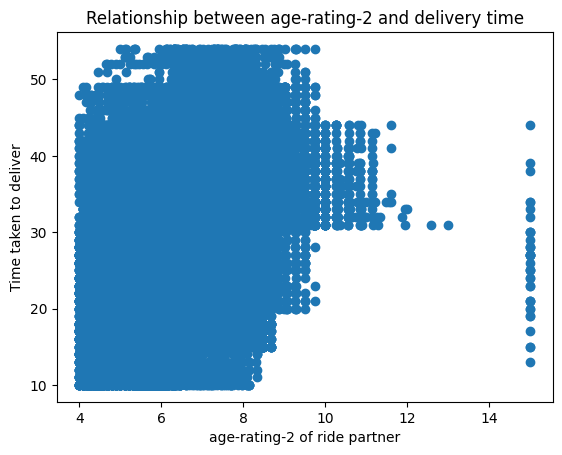

In [15]:
plt.scatter(x2,y) 
plt.xlabel('age-rating-2 of ride partner')
plt.ylabel('Time taken to deliver')
plt.title('Relationship between age-rating-2 and delivery time')

In [16]:
# just the numeric features are not helpful. So we need to do binning.
df['Delivery_person_Age'].describe()

count    45593.000000
mean        29.544075
std          5.696793
min         15.000000
25%         25.000000
50%         29.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [17]:
df[df['Delivery_person_Age']<18].shape

(38, 13)

In [18]:
# In India it is illegal to work under age of 18. Believing companies work with fair policies,
# we drop those data where age<18
df=df[df['Delivery_person_Age']>=18]

In [19]:
df.shape

(45555, 13)

In [20]:
df['Delivery_person_Age'].describe()

count    45555.000000
mean        29.556207
std          5.683654
min         20.000000
25%         25.000000
50%         29.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


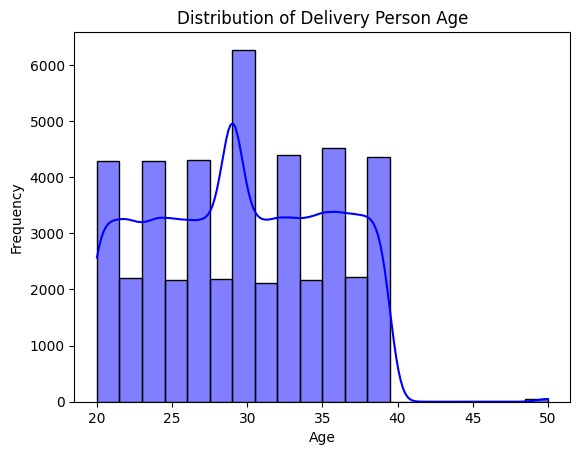

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the histogram
sns.histplot(df['Delivery_person_Age'], kde=True, bins=20, color='blue')

# Add labels and title
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery Person Age')

# Show the plot
plt.show()

In [22]:
def classify_age_group(age):
    if 20 <= age < 30:
        return 0.0
    elif 30 <= age <= 40:
        return 1.0
    else:
        return 2.0
df['age-group'] = df['Delivery_person_Age'].apply(classify_age_group)


    

<ipython-input-22-418012e0ae55>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['age-group'] = df['Delivery_person_Age'].apply(classify_age_group)


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


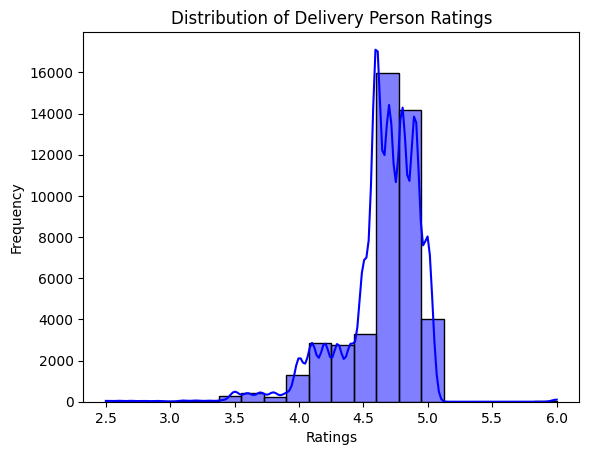

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the histogram
sns.histplot(df['Delivery_person_Ratings'], kde=True, bins=20, color='blue')

# Add labels and title
plt.xlabel('Ratings')
plt.ylabel('Frequency')
plt.title('Distribution of Delivery Person Ratings')

# Show the plot
plt.show()

In [24]:
df=df[df['Delivery_person_Ratings']>=2.5]

In [25]:
df.shape

(45555, 14)

In [26]:
def classify_ratings_group(rating):
    if 2.5 <= rating < 4:
        return 0.0
    elif 4<= rating < 4.5:
        return 1.0
    elif 4.5<=rating<5:
        return 2.0
    else:
        return 3.0
df['rating-group'] = df['Delivery_person_Ratings'].apply(classify_ratings_group)

In [27]:
df.groupby(by='rating-group')['Time_taken(min)'].mean()

rating-group
0.0    37.142965
1.0    34.647946
2.0    24.288842
3.0    25.510496
Name: Time_taken(min), dtype: float64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

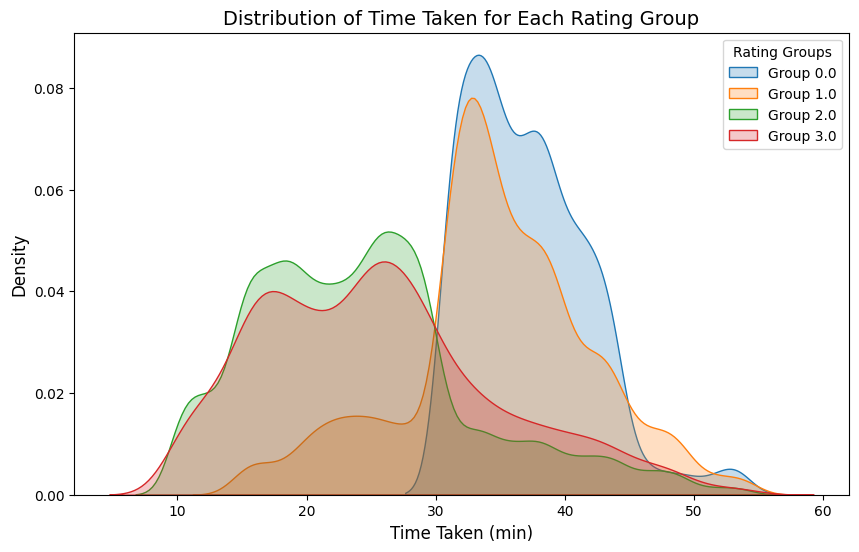

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'rating-group' is the column created by your binning
rating_groups = df.groupby('rating-group')['Time_taken(min)']

# Plot distributions for each group
plt.figure(figsize=(10, 6))
for group, values in rating_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each Rating Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Rating Groups')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


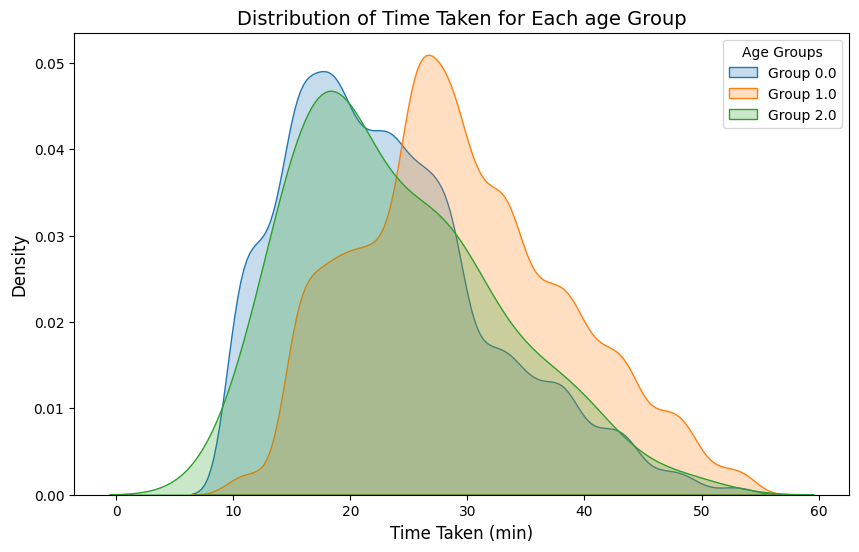

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'rating-group' is the column created by your binning
age_groups = df.groupby('age-group')['Time_taken(min)']

# Plot distributions for each group
plt.figure(figsize=(10, 6))
for group, values in age_groups:
    sns.kdeplot(values, label=f'Group {group}', fill=True)

plt.title('Distribution of Time Taken for Each age Group', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Age Groups')
plt.show()

In [30]:
df['age-group'].value_counts()

age-group
0.0    23489
1.0    22013
2.0       53
Name: count, dtype: int64

In [31]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'age-rating-1', 'age-rating-2', 'age-group',
       'rating-group'],
      dtype='object')

In [32]:
import pandas as pd
from haversine import haversine, Unit
def calculate_distance(row):
    point1 = (row['Restaurant_latitude'], row['Restaurant_longitude'])
    point2 = (row['Delivery_location_latitude'], row['Delivery_location_longitude'])
    return haversine(point1, point2, unit=Unit.KILOMETERS)


df['distance_km'] = df.apply(calculate_distance, axis=1)




In [33]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'age-rating-1', 'age-rating-2', 'age-group',
       'rating-group', 'distance_km'],
      dtype='object')

In [34]:
x=df['distance_km']
y=df['Time_taken(min)']

Text(0.5, 1.0, 'distance v/s time')

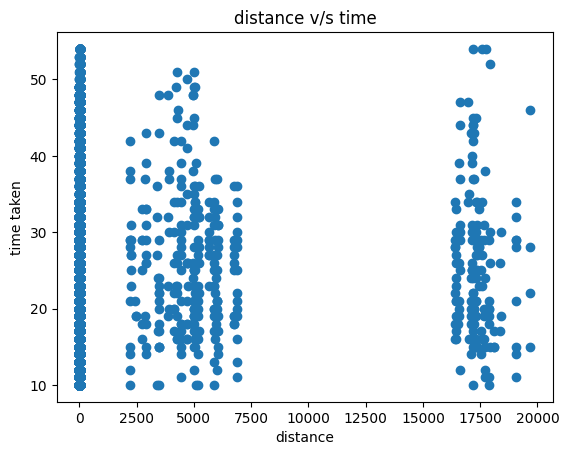

In [35]:
plt.scatter(x,y)
plt.xlabel('distance')
plt.ylabel('time taken')
plt.title('distance v/s time')

In [36]:
df['Time_taken(min)'].corr(df['age-group'])

0.331029994681826

In [37]:
df['distance_km'].corr(df['Time_taken(min)'])

-0.0028853192714423602

In [38]:
# This means distance_km is not a good feature. 
df['horizontal_difference'] = abs(df['Restaurant_latitude'] - df['Delivery_location_latitude'])
df['vertical_difference'] = abs(df['Restaurant_longitude'] - df['Delivery_location_longitude'])
df['distance'] = np.sqrt(df['horizontal_difference']**2 + df['vertical_difference']**2)


In [39]:
df['horizontal_difference'].corr(df['Time_taken(min)'])

-0.0025643094083360636

In [40]:
df['vertical_difference'].corr(df['Time_taken(min)'])

-0.0024766074147751266

In [41]:
df['distance'].corr(df['Time_taken(min)'])

-0.0029509830497087214

In [42]:

avg_ratings = {}
for x in df['age-group'].unique():
    avg_ratings[x] = df[df['age-group'] == x]['Delivery_person_Ratings'].mean()

# Map the average ratings to a new column
df['average_rating_age'] = df['age-group'].map(avg_ratings)


In [43]:
df['time-taken-age']=df['Time_taken(min)']/df['Delivery_person_Age']

In [44]:
df['time-taken-ratings']=df['Time_taken(min)']/df['Delivery_person_Ratings']

[]

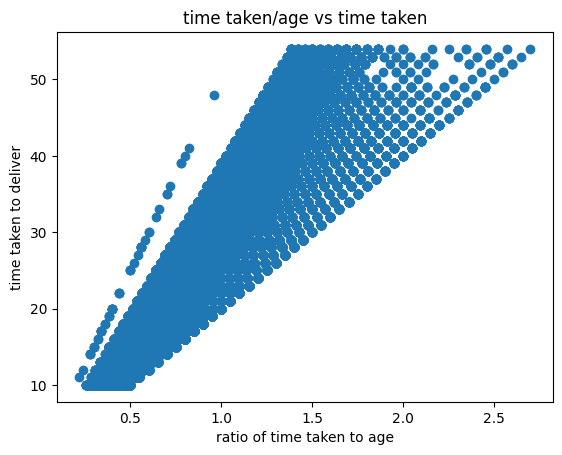

In [45]:
x=df['time-taken-age']
y=df['Time_taken(min)']
plt.scatter(x,y)
plt.xlabel('ratio of time taken to age')
plt.ylabel('time taken to deliver')
plt.title('time taken/age vs time taken')
plt.plot()

[]

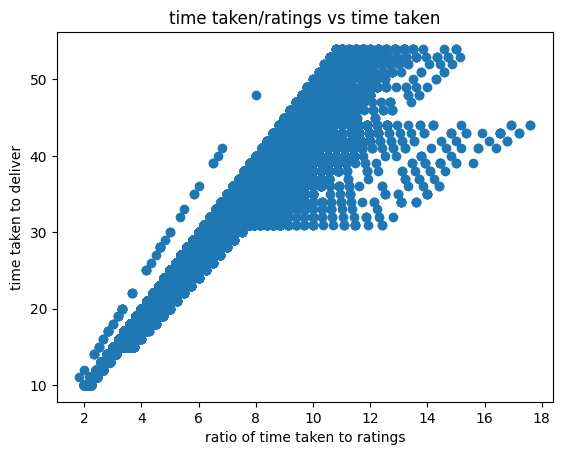

In [46]:
x=df['time-taken-ratings']
y=df['Time_taken(min)']
plt.scatter(x,y)
plt.xlabel('ratio of time taken to ratings')
plt.ylabel('time taken to deliver')
plt.title('time taken/ratings vs time taken')
plt.plot()

In [47]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Type_of_order', 'Type_of_vehicle',
       'Time_taken(min)', 'age-rating-1', 'age-rating-2', 'age-group',
       'rating-group', 'distance_km', 'horizontal_difference',
       'vertical_difference', 'distance', 'average_rating_age',
       'time-taken-age', 'time-taken-ratings'],
      dtype='object')

In [48]:
df['Type_of_order'].value_counts()

Type_of_order
Snack      11521
Meal       11450
Drinks     11314
Buffet     11270
Name: count, dtype: int64

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


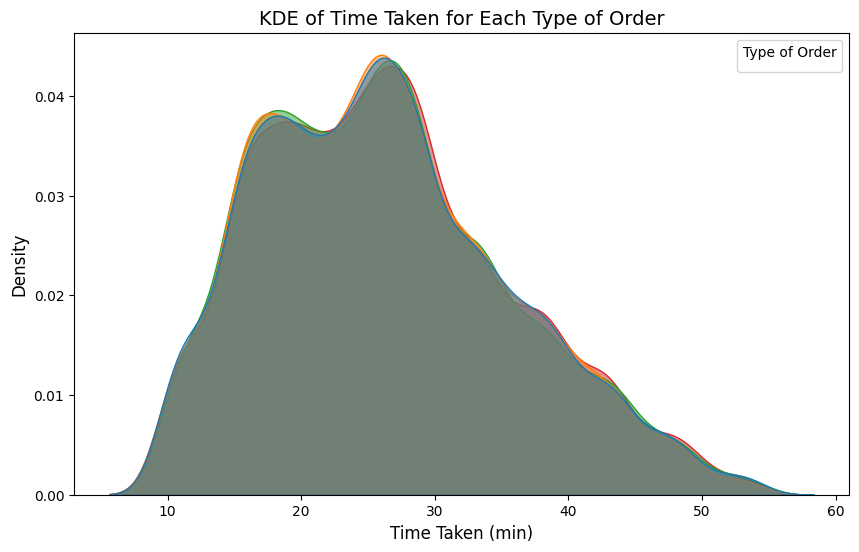

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot KDE for each unique 'Type_of_order'
sns.kdeplot(data=df, x='Time_taken(min)', hue='Type_of_order', fill=True, common_norm=False, alpha=0.5)

# Add labels and title
plt.title('KDE of Time Taken for Each Type of Order', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Type of Order')
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


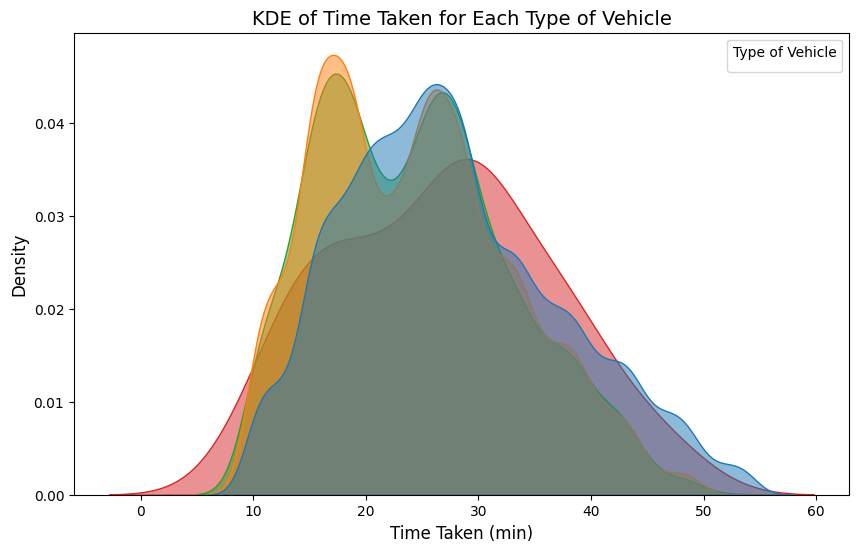

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot KDE for each unique 'Type_of_order'
sns.kdeplot(data=df, x='Time_taken(min)', hue='Type_of_vehicle', fill=True, common_norm=False, alpha=0.5)

# Add labels and title
plt.title('KDE of Time Taken for Each Type of Vehicle', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Type of Vehicle')
plt.show()

In [51]:
# Combine type of vehicle and type of order
df['vehicle_order_type']=df['Type_of_vehicle']+'_'+df['Type_of_order']

In [52]:
df['vehicle_order_type'].unique()

array(['motorcycle _Snack ', 'scooter _Snack ', 'motorcycle _Drinks ',
       'motorcycle _Buffet ', 'scooter _Meal ', 'motorcycle _Meal ',
       'scooter _Drinks ', 'electric_scooter _Buffet ',
       'electric_scooter _Meal ', 'scooter _Buffet ',
       'electric_scooter _Drinks ', 'electric_scooter _Snack ',
       'bicycle _Meal ', 'bicycle _Buffet ', 'bicycle _Drinks ',
       'bicycle _Snack '], dtype=object)

In [53]:
df['Type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


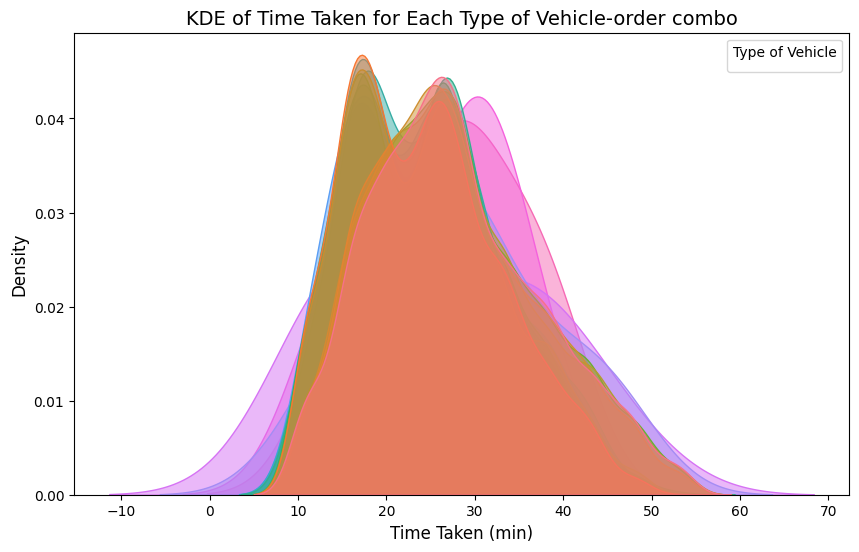

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot KDE for each unique 'Type_of_order'
sns.kdeplot(data=df, x='Time_taken(min)', hue='vehicle_order_type', fill=True, common_norm=False, alpha=0.5)

# Add labels and title
plt.title('KDE of Time Taken for Each Type of Vehicle-order combo', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Type of Vehicle')
plt.show()

In [55]:
# Map age-group values to labels
age_group_map = {0.0: 'c0', 1.0: 'c1', 2.0: 'c2'}
df['age-group-text'] = df['age-group'].map(age_group_map)

# Ensure other columns are clean strings
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()
df['Type_of_order'] = df['Type_of_order'].str.strip()

# Perform concatenations
df['vehicle_type_age_group'] = df['Type_of_vehicle'] + '_' + df['age-group-text']
df['order_type_age_group'] = df['Type_of_order'] + '_' + df['age-group-text']
df['order_vehicle_age_group'] = (
    df['Type_of_vehicle'] + '_' + df['Type_of_order'] + '_' + df['age-group-text']
)


In [56]:
df['Type_of_vehicle'].unique()

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

In [57]:
df['age-group'].unique()

array([1., 0., 2.])

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


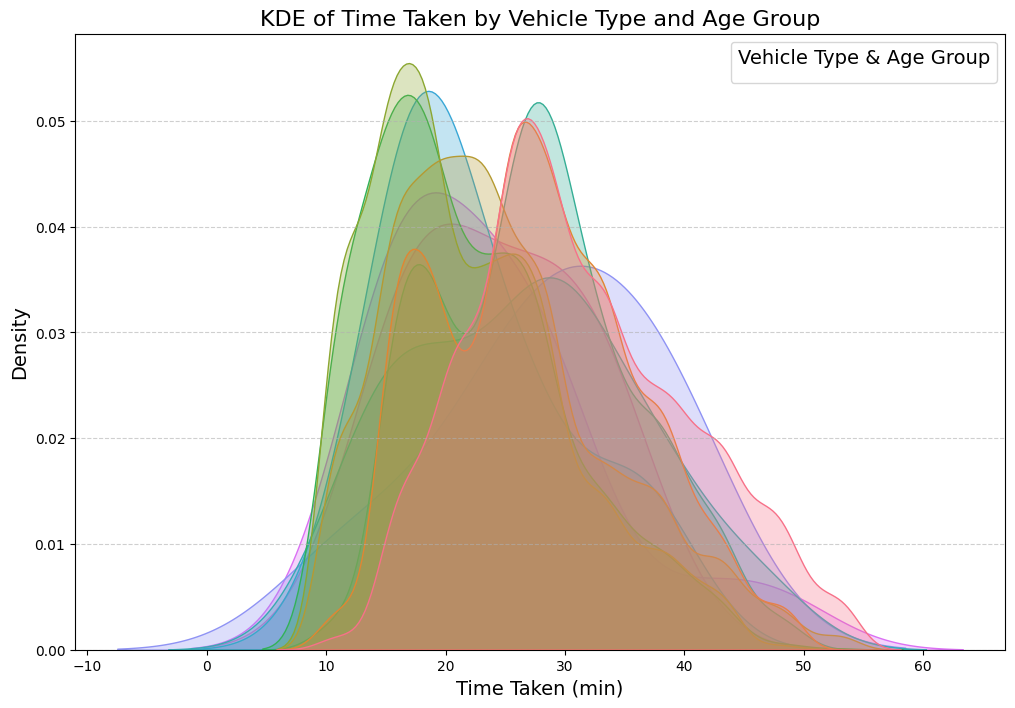

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot KDE for each unique 'vehicle_type_age_group'
sns.kdeplot(
    data=df,
    x='Time_taken(min)',
    hue='vehicle_type_age_group',  # Ensure the column name matches the DataFrame
    fill=True,
    common_norm=False,
    alpha=0.3
)

# Add labels, title, and legend
plt.title('KDE of Time Taken by Vehicle Type and Age Group', fontsize=16)
plt.xlabel('Time Taken (min)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Vehicle Type & Age Group', fontsize=12, title_fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


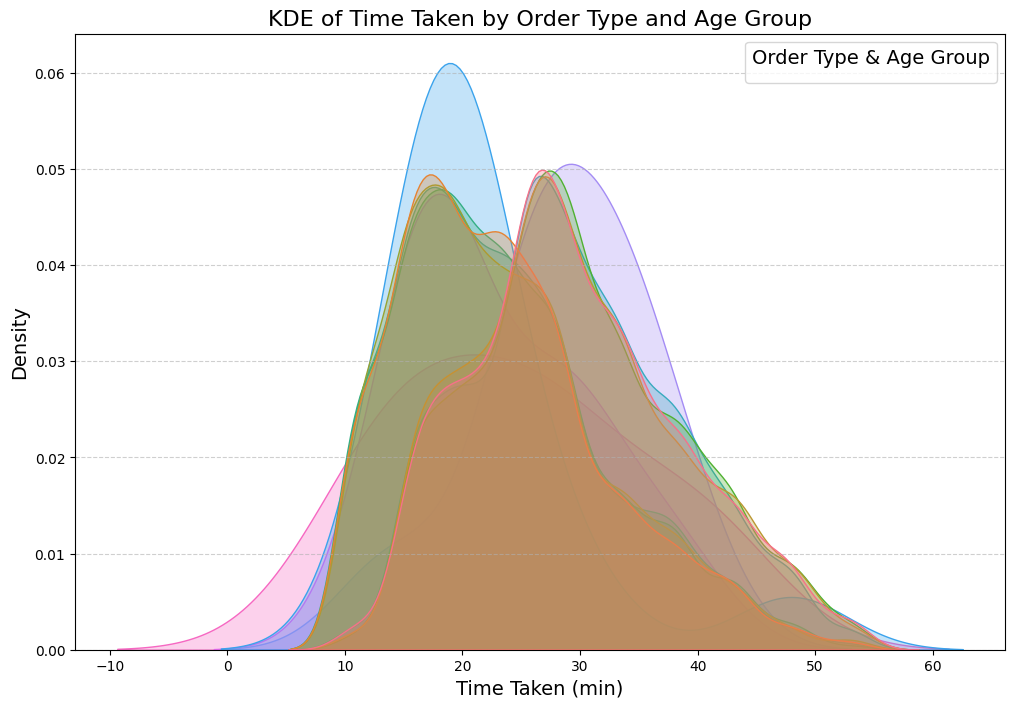

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(12, 8))

# Plot KDE for each unique 'order_type_age_group'
sns.kdeplot(
    data=df,
    x='Time_taken(min)',
    hue='order_type_age_group',  # Ensure the column name matches the DataFrame
    fill=True,
    common_norm=False,
    alpha=0.3
)

# Add labels, title, and legend
plt.title('KDE of Time Taken by Order Type and Age Group', fontsize=16)
plt.xlabel('Time Taken (min)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(title='Order Type & Age Group', fontsize=12, title_fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Show the plot
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-60-42f58962e080>:8: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue='order_vehicle_age_group', fill=True, common_norm=False, alpha=0.5)


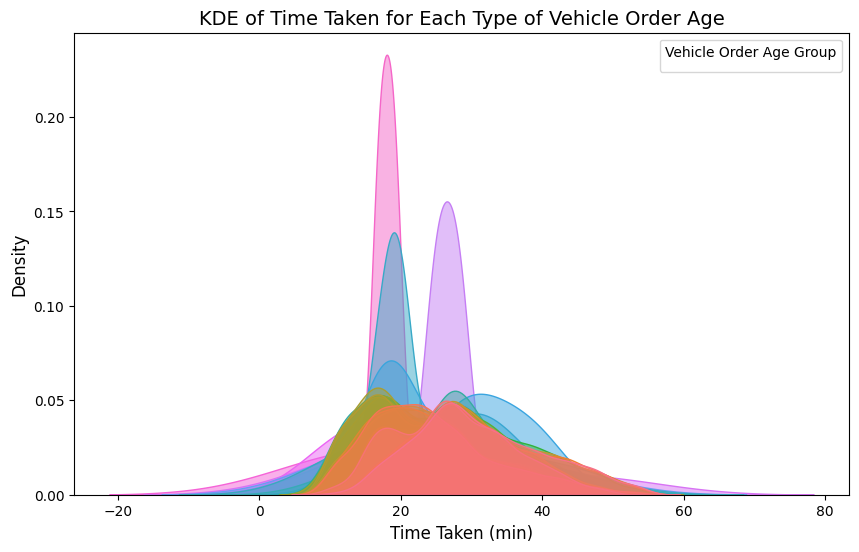

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(10, 6))

# Plot KDE for each unique 'order_vehicle_age_group'
sns.kdeplot(data=df, x='Time_taken(min)', hue='order_vehicle_age_group', fill=True, common_norm=False, alpha=0.5)

# Add labels and title
plt.title('KDE of Time Taken for Each Type of Vehicle Order Age', fontsize=14)
plt.xlabel('Time Taken (min)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Vehicle Order Age Group')

# Show plot
plt.show()


In [61]:
# USING THE COLUMN DELIVERY_PERSON_ID TO GET THE CITIES 
df['Delivery_person_ID'].unique()

array(['INDORES13DEL02', 'BANGRES18DEL02', 'BANGRES19DEL01', ...,
       'KOCRES04DEL01', 'BHPRES06DEL03', 'GOARES03DEL03'], dtype=object)

### With some common GK it was not difficult to observe that all those were nothing but name of the cities. We will now create some more combinations and categorical features

In [62]:
df['Delivery_person_ID'] = df['Delivery_person_ID'].str.lower().str.replace(r'[^a-z]', '', regex=True)

In [63]:
df['Delivery_person_ID'].unique()

array(['indoresdel', 'bangresdel', 'coimbresdel', 'chenresdel',
       'hydresdel', 'ranchiresdel', 'mysresdel', 'dehresdel', 'kocresdel',
       'puneresdel', 'ludhresdel', 'knpresdel', 'mumresdel', 'kolresdel',
       'japresdel', 'surresdel', 'goaresdel', 'aurgresdel', 'agrresdel',
       'vadresdel', 'alhresdel', 'bhpresdel'], dtype=object)

In [64]:
df.rename(columns={'Delivery_person_ID': 'cities'}, inplace=True)

In [65]:
df.columns

Index(['ID', 'cities', 'Delivery_person_Age', 'Delivery_person_Ratings',
       'Restaurant_latitude', 'Restaurant_longitude',
       'Delivery_location_latitude', 'Delivery_location_longitude',
       'Type_of_order', 'Type_of_vehicle', 'Time_taken(min)', 'age-rating-1',
       'age-rating-2', 'age-group', 'rating-group', 'distance_km',
       'horizontal_difference', 'vertical_difference', 'distance',
       'average_rating_age', 'time-taken-age', 'time-taken-ratings',
       'vehicle_order_type', 'age-group-text', 'vehicle_type_age_group',
       'order_type_age_group', 'order_vehicle_age_group'],
      dtype='object')

In [66]:
df['cities_vehicle_type']=df['cities']+df['Type_of_vehicle']
df['cities_order_type']=df['cities']+df['Type_of_order']
df['cities_age_group_type']=df['cities']+df['age-group-text']
df['cities_vehicle_age_type']=df['cities']+df['Type_of_vehicle']+df['age-group-text']
df['cities_order_age_type']=df['cities']+df['Type_of_order']+df['age-group-text']
df['cities_vehicle_order_type']=df['cities']+df['Type_of_vehicle']+df['Type_of_order']
df['cities_vehicle_order_age_type']=df['cities']+df['Type_of_vehicle']+df['Type_of_order']+df['age-group-text']


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


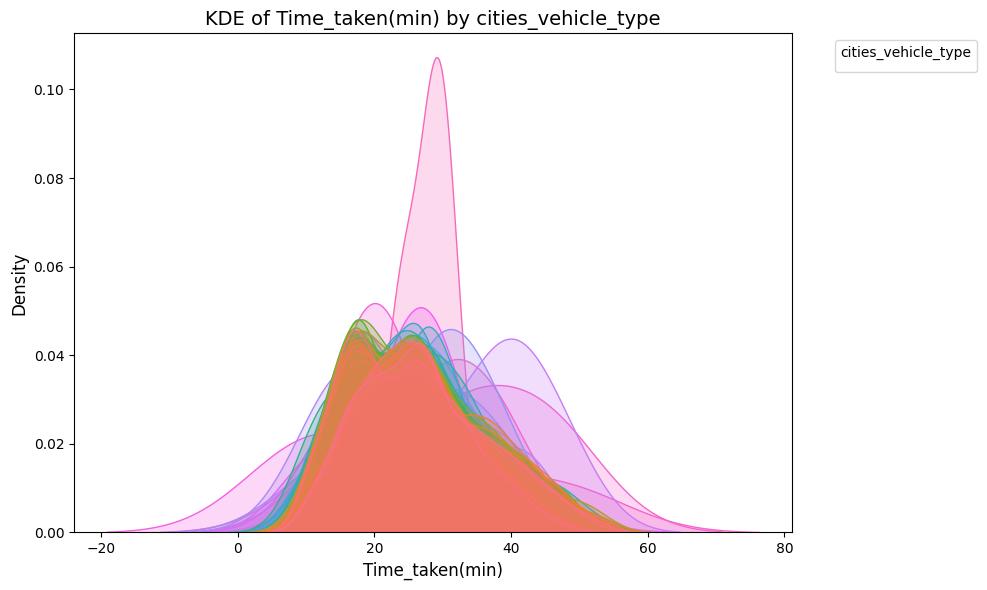

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


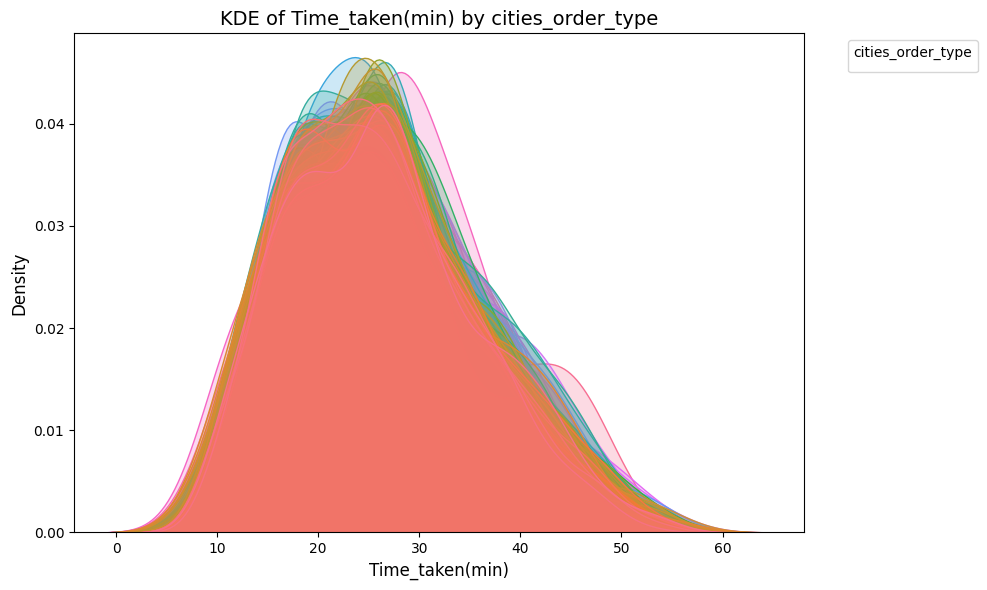

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


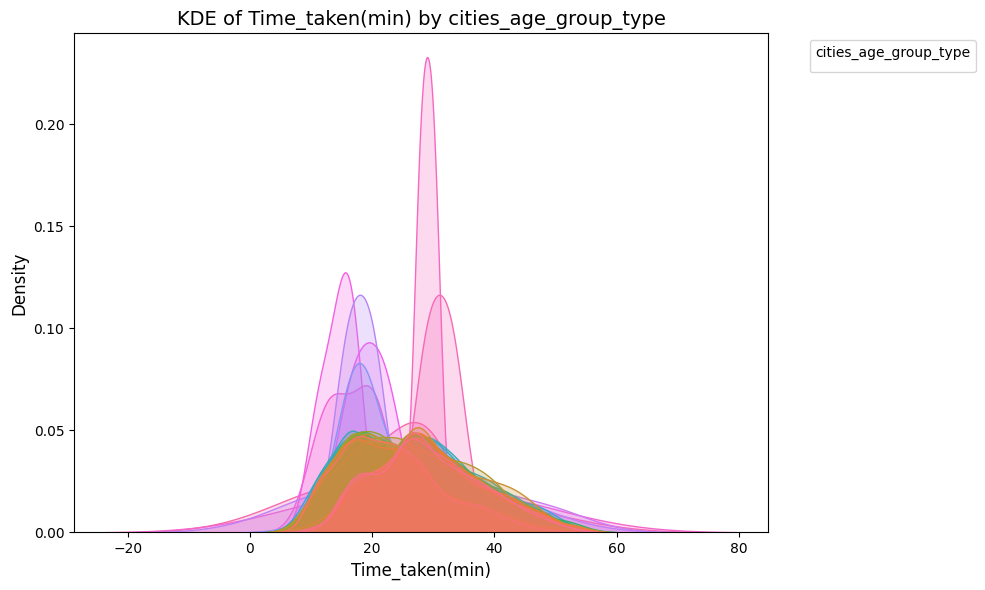

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


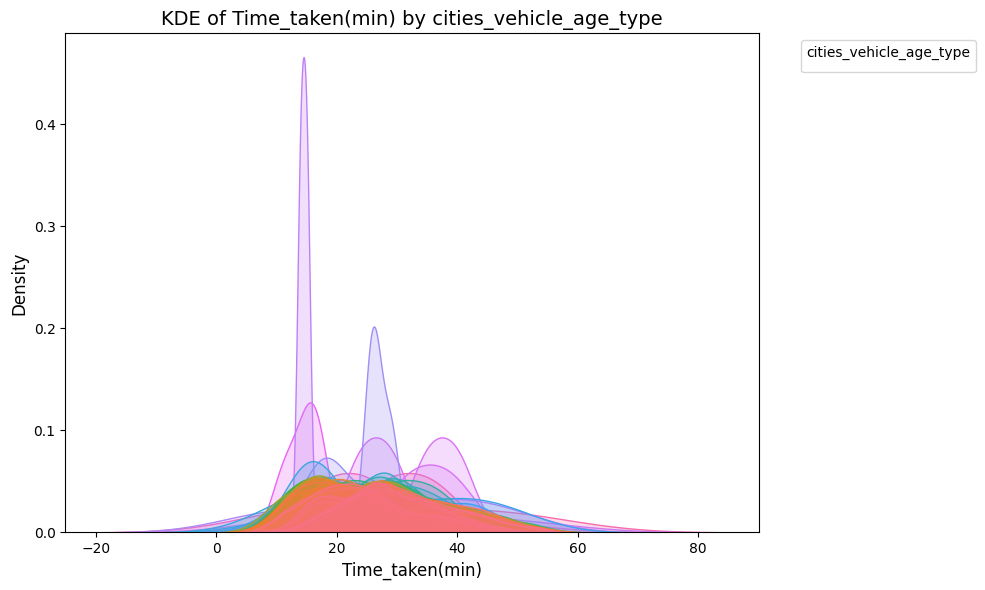

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


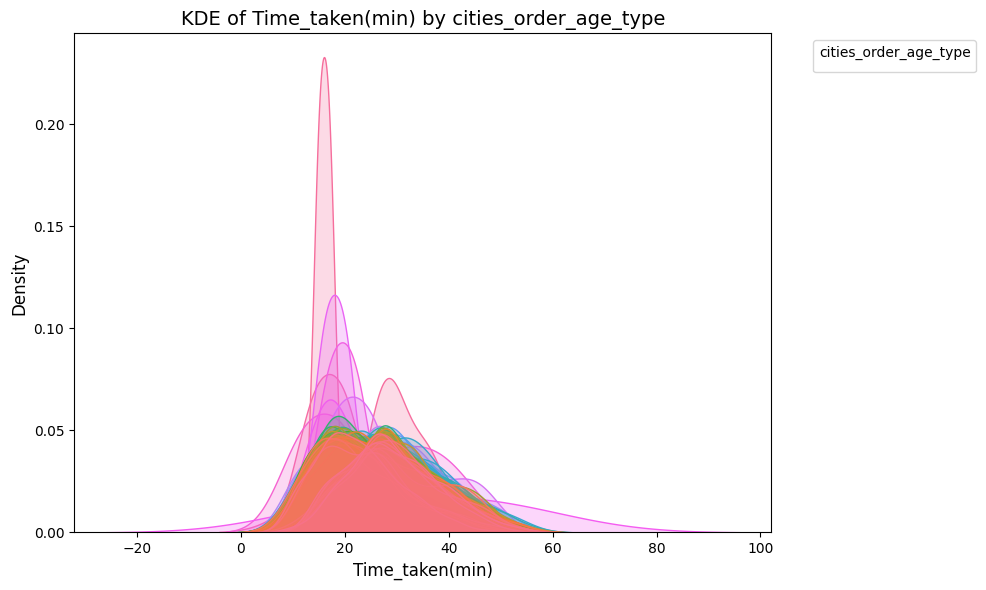

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


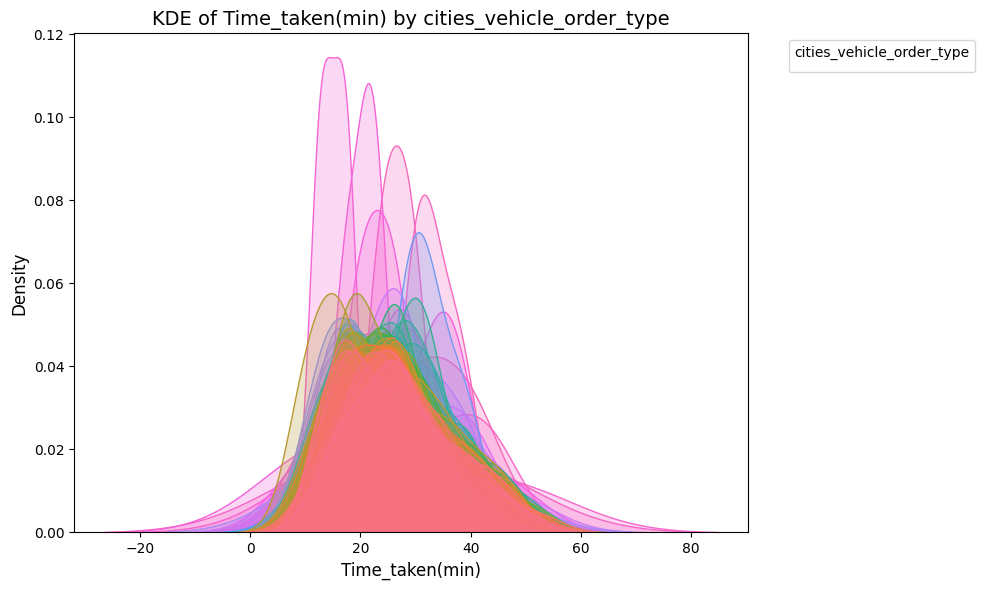

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
<ipython-input-67-cbed47acc286>:18: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)


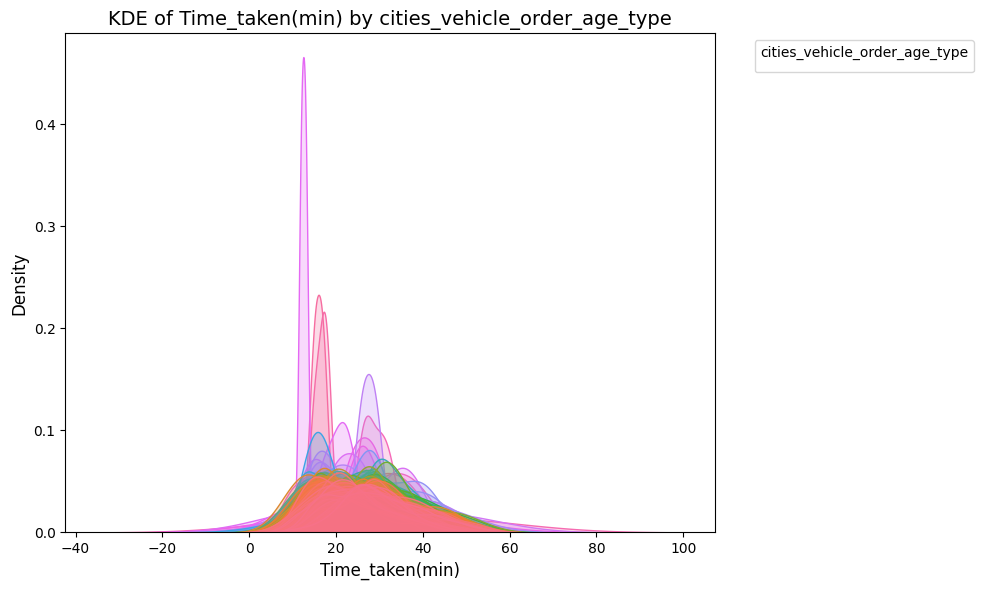

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of new features to plot
new_features = [
    'cities_vehicle_type',
    'cities_order_type',
    'cities_age_group_type',
    'cities_vehicle_age_type',
    'cities_order_age_type',
    'cities_vehicle_order_type',
    'cities_vehicle_order_age_type'
]

# Iterate through each feature and plot its KDE
for feature in new_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Time_taken(min)', hue=feature, common_norm=False, fill=True)
    plt.title(f'KDE of Time_taken(min) by {feature}', fontsize=14)
    plt.xlabel('Time_taken(min)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(title=feature, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [68]:
categorical_columns=[]
for c in df.columns:
    if df[c].dtype==object:
        categorical_columns.append(c)

In [69]:
categorical_columns

['ID',
 'cities',
 'Type_of_order',
 'Type_of_vehicle',
 'vehicle_order_type',
 'age-group-text',
 'vehicle_type_age_group',
 'order_type_age_group',
 'order_vehicle_age_group',
 'cities_vehicle_type',
 'cities_order_type',
 'cities_age_group_type',
 'cities_vehicle_age_type',
 'cities_order_age_type',
 'cities_vehicle_order_type',
 'cities_vehicle_order_age_type']

In [70]:
categorical_columns.remove('ID')


### Understanding encodings for categorical columns 

In [71]:
# Algorithms like gbdt's perform well when there are many encodings of categorical features given to them.
# Pattern detection becomes much easier. In this dataset, we can already see how
# columns don't have much correlation with target column. 
# so we provide all 7 types of encoding for all categorical colums

In [72]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
encoded_features = {}
for col in categorical_columns:
    
    le = LabelEncoder()
    df[f'{col}_label'] = le.fit_transform(df[col])
    
    
    group = df.groupby(col)['Time_taken(min)']
    
    
    df[f'{col}_mean'] = df[col].map(group.mean())
    df[f'{col}_median'] = df[col].map(group.median())
    df[f'{col}_min'] = df[col].map(group.min())
    df[f'{col}_max'] = df[col].map(group.max())
    df[f'{col}_count'] = df[col].map(group.size())
    
    # Save encoded columns
    encoded_features[col] = [f'{col}_label', f'{col}_mean', f'{col}_median', f'{col}_min', f'{col}_max', f'{col}_count']




<ipython-input-72-ccfc75a3cfa2>:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_median'] = df[col].map(group.median())
<ipython-input-72-ccfc75a3cfa2>:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{col}_min'] = df[col].map(group.min())
<ipython-input-72-ccfc75a3cfa2>:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 

In [73]:
df

,ID,cities,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,...,cities_vehicle_order_type_median,cities_vehicle_order_type_min,cities_vehicle_order_type_max,cities_vehicle_order_type_count,cities_vehicle_order_age_type_label,cities_vehicle_order_age_type_mean,cities_vehicle_order_age_type_median,cities_vehicle_order_age_type_min,cities_vehicle_order_age_type_max,cities_vehicle_order_age_type_count
0,4607,indoresdel,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,...,26.0,10,54,460,298,30.766520,29.0,10,54,227
1,B379,bangresdel,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,...,22.0,10,47,286,106,26.101449,25.0,11,47,138
2,5D6D,bangresdel,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,...,26.0,10,54,462,92,23.731405,23.0,10,53,242
3,7A6A,coimbresdel,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,...,26.0,10,54,444,183,30.102679,28.0,14,54,224
4,70A2,chenresdel,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,...,23.0,10,49,269,165,27.611111,28.0,10,49,126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,7C09,japresdel,30,4.8,26.902328,75.794257,26.912328,75.804257,Meal,motorcycle,...,27.0,10,54,506,326,31.917323,31.0,12,54,254
45589,D641,agrresdel,21,4.6,0.000000,0.000000,0.070000,0.070000,Buffet,motorcycle,...,27.0,10,54,112,10,23.793103,21.5,10,41,58
45590,4F8D,chenresdel,30,4.9,13.022394,80.242439,13.052394,80.272439,Drinks,scooter,...,23.0,10,46,290,160,27.370629,27.0,10,46,143
45591,5EEE,coimbresdel,20,4.7,11.001753,76.986241,11.041753,77.026241,Snack,motorcycle,...,26.0,10,54,446,188,23.056338,21.0,10,54,213


# Feature Selection

In [74]:
lec=[]
for col in categorical_columns:
    lec.append(f'{col}_label')
    

In [75]:
import xgboost as xgb
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error



# Prepare the features (all categorical columns) and target variable
X = df[lec]
y = df['Time_taken(min)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Calculate and display feature importances
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': lec, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"\nRMSE: {rmse}")


Feature Importances:
                                Feature  Importance
4                  age-group-text_label    0.668901
5          vehicle_type_age_group_label    0.151514
2                 Type_of_vehicle_label    0.112148
9               cities_order_type_label    0.014709
13      cities_vehicle_order_type_label    0.006215
0                          cities_label    0.006026
14  cities_vehicle_order_age_type_label    0.005760
12          cities_order_age_type_label    0.005275
1                   Type_of_order_label    0.005024
8             cities_vehicle_type_label    0.004882
3              vehicle_order_type_label    0.004696
6            order_type_age_group_label    0.003914
7         order_vehicle_age_group_label    0.003871
10          cities_age_group_type_label    0.003813
11        cities_vehicle_age_type_label    0.003252

RMSE: 8.741276897380594


In [76]:
# We will select only the most important categorical features. AFTER 0.11 next important 
# feature is from 0.01 which is ten times low. so we take threshold to be 0.11

In [77]:
cat_columns_to_be_used=['age-group-text','vehicle_type_age_group','Type_of_vehicle']
                       


In [78]:
for c in df.columns:
    if df[c].dtype!=object:
        print(''+c+',')

Delivery_person_Age,
Delivery_person_Ratings,
Restaurant_latitude,
Restaurant_longitude,
Delivery_location_latitude,
Delivery_location_longitude,
Time_taken(min),
age-rating-1,
age-rating-2,
age-group,
rating-group,
distance_km,
horizontal_difference,
vertical_difference,
distance,
average_rating_age,
time-taken-age,
time-taken-ratings,
cities_label,
cities_mean,
cities_median,
cities_min,
cities_max,
cities_count,
Type_of_order_label,
Type_of_order_mean,
Type_of_order_median,
Type_of_order_min,
Type_of_order_max,
Type_of_order_count,
Type_of_vehicle_label,
Type_of_vehicle_mean,
Type_of_vehicle_median,
Type_of_vehicle_min,
Type_of_vehicle_max,
Type_of_vehicle_count,
vehicle_order_type_label,
vehicle_order_type_mean,
vehicle_order_type_median,
vehicle_order_type_min,
vehicle_order_type_max,
vehicle_order_type_count,
age-group-text_label,
age-group-text_mean,
age-group-text_median,
age-group-text_min,
age-group-text_max,
age-group-text_count,
vehicle_type_age_group_label,
vehicle_type_ag

In [79]:
numeric_columns=['Delivery_person_Age',
'Delivery_person_Ratings',
'Restaurant_latitude',
'Restaurant_longitude',
'Delivery_location_latitude',
'Delivery_location_longitude',
 'age-rating-1',
'age-rating-2',
'horizontal_difference',
'vertical_difference',
'distance',
'average_rating_age',
'time-taken-age',
'time-taken-ratings']

In [80]:
X = df[numeric_columns]
y = df['Time_taken(min)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Calculate and display feature importances
feature_importances = model.feature_importances_
importance_df = pd.DataFrame({'Feature': numeric_columns, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"\nRMSE: {rmse}")

Feature Importances:
                        Feature  Importance
13           time-taken-ratings    0.942455
1       Delivery_person_Ratings    0.034266
12               time-taken-age    0.010145
8         horizontal_difference    0.005577
6                  age-rating-1    0.005497
0           Delivery_person_Age    0.001294
7                  age-rating-2    0.000345
4    Delivery_location_latitude    0.000115
2           Restaurant_latitude    0.000107
3          Restaurant_longitude    0.000094
5   Delivery_location_longitude    0.000063
9           vertical_difference    0.000042
10                     distance    0.000000
11           average_rating_age    0.000000

RMSE: 0.14769907539317037


In [81]:
numerical_columns_to_be_used=['time-taken-ratings','Delivery_person_Ratings',
                             'time-taken-age','horizontal_difference',
                             'age-rating-1','Delivery_person_Age']


# Model Building 

In [82]:

final_columns_to_be_used=[]
for col in cat_columns_to_be_used:
    final_columns_to_be_used.append(f'{col}_label')
    final_columns_to_be_used.append(f'{col}_mean')
    final_columns_to_be_used.append(f'{col}_median')
    final_columns_to_be_used.append(f'{col}_max')
    final_columns_to_be_used.append(f'{col}_min')
    final_columns_to_be_used.append(f'{col}_count')
for col in numerical_columns_to_be_used:
    final_columns_to_be_used.append(col)
    
    

In [83]:
final_columns_to_be_used

['age-group-text_label',
 'age-group-text_mean',
 'age-group-text_median',
 'age-group-text_max',
 'age-group-text_min',
 'age-group-text_count',
 'vehicle_type_age_group_label',
 'vehicle_type_age_group_mean',
 'vehicle_type_age_group_median',
 'vehicle_type_age_group_max',
 'vehicle_type_age_group_min',
 'vehicle_type_age_group_count',
 'Type_of_vehicle_label',
 'Type_of_vehicle_mean',
 'Type_of_vehicle_median',
 'Type_of_vehicle_max',
 'Type_of_vehicle_min',
 'Type_of_vehicle_count',
 'time-taken-ratings',
 'Delivery_person_Ratings',
 'time-taken-age',
 'horizontal_difference',
 'age-rating-1',
 'Delivery_person_Age']

In [84]:
X = df[final_columns_to_be_used]
y = df['Time_taken(min)']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the XGBoost model
model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Fit the model
model.fit(X_train, y_train)




# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"\nRMSE: {rmse}")


RMSE: 0.1572353983400743


In [85]:
from sklearn.metrics import r2_score


r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.9997175732212741


# Results visualisation

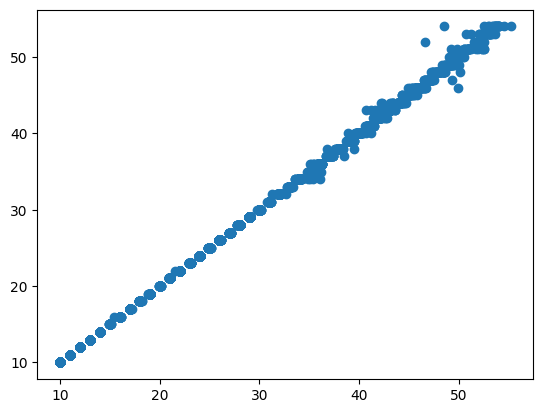

In [86]:
plt.scatter(y_pred,y_test)

### Visualising fit of predicted and original values and residual distribution 

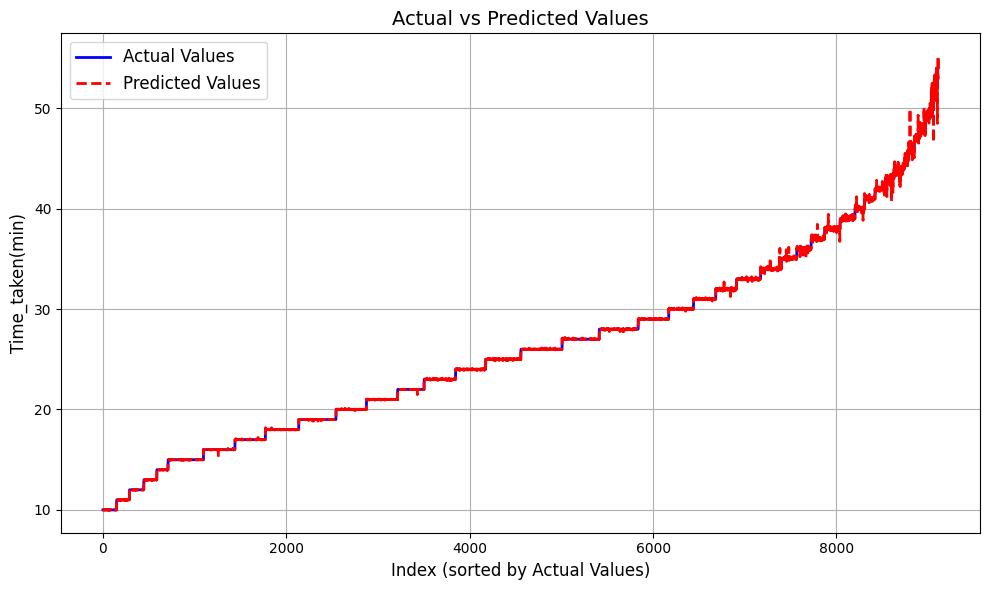

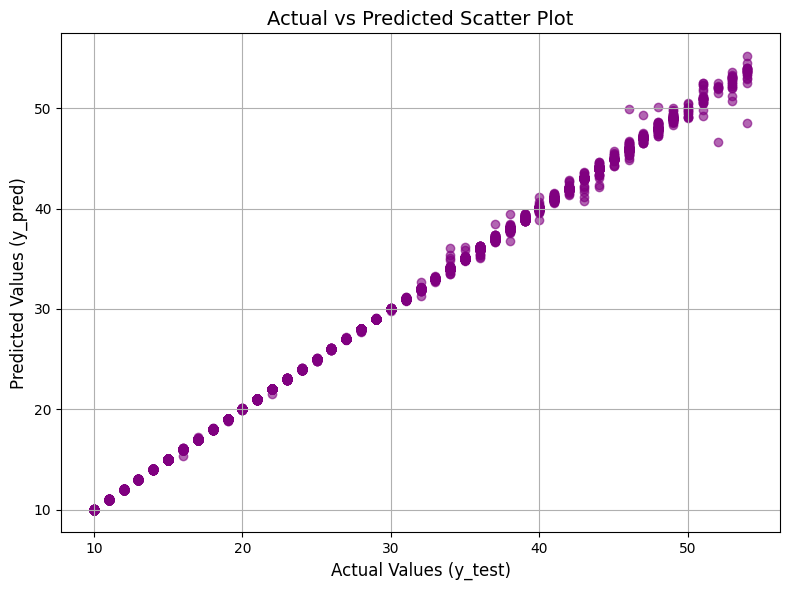

In [87]:
import matplotlib.pyplot as plt
import numpy as np

# Sort values for better visualization
y_test_sorted = np.array(y_test)
y_pred_sorted = np.array(y_pred)

# Sort based on y_test for a clearer comparison
sorted_indices = np.argsort(y_test_sorted)
y_test_sorted = y_test_sorted[sorted_indices]
y_pred_sorted = y_pred_sorted[sorted_indices]

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.plot(y_test_sorted, label='Actual Values', color='blue', linewidth=2)
plt.plot(y_pred_sorted, label='Predicted Values', color='red', linestyle='--', linewidth=2)
plt.title("Actual vs Predicted Values", fontsize=14)
plt.xlabel("Index (sorted by Actual Values)", fontsize=12)
plt.ylabel("Time_taken(min)", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# Scatter plot for error distribution
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.title("Actual vs Predicted Scatter Plot", fontsize=14)
plt.xlabel("Actual Values (y_test)", fontsize=12)
plt.ylabel("Predicted Values (y_pred)", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


# Cross validation scores to confirm absence of overfitting 

In [88]:
from sklearn.model_selection import cross_val_score

# Assuming your model is 'model' and X, y are your feature matrix and target vector
cv_scores = cross_val_score(model, X, y, cv=5)  # cv=5 means 5-fold cross-validation

print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation of CV scores:", cv_scores.std())


Cross-validation scores: [0.99980953 0.99976775 0.99983046 0.99981614 0.99961394]
Mean CV score: 0.9997675638659871
Standard deviation of CV scores: 7.95953821122943e-05


# Hyperparameter fine tuning 

### Although we already have got a very high accuarcy, but in today's competitive world, an improvement of even 0.0001 can bring a lot of positive effect  


In [89]:
import optuna
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Assuming X and y are your feature matrix and target vector
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the objective function
def objective(trial):
    # Hyperparameter search space
    params = {
        'objective': 'reg:squarederror',  # Regression task
        'eval_metric': 'rmse',  # Root Mean Squared Error
        'max_depth': trial.suggest_int('max_depth', 3, 12),  # Depth of the tree
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),  # Step size
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),  # Number of trees
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),  # Fraction of samples used in training
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # Fraction of features used
        'gamma': trial.suggest_float('gamma', 0, 1),  # Regularization term
        'alpha': trial.suggest_float('alpha', 0, 1)  # L1 regularization term
    }
    
    # Create the model with the parameters
    model = xgb.XGBRegressor(**params)
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on the validation set
    y_pred = model.predict(X_valid)
    
    # Calculate RSE (Relative Squared Error)
    rse = ((y_valid - y_pred) ** 2).sum() / ((y_valid - y_valid.mean()) ** 2).sum()
    
    return rse

# Create the Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# Get the best parameters found by Optuna
best_params = study.best_params
print("Best hyperparameters:", best_params)

# Train the model with the best hyperparameters
best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

# Make predictions using the best model
y_pred_best = best_model.predict(X_valid)

# Calculate R² score for the best model
r2 = r2_score(y_valid, y_pred_best)
print("R² Score for the best model:", r2)


[I 2025-01-07 19:38:39,885] A new study created in memory with name: no-name-febf848a-819a-4808-a944-38ddfffadedb
[I 2025-01-07 19:38:40,210] Trial 0 finished with value: 0.0004560692372830437 and parameters: {'max_depth': 9, 'learning_rate': 0.2014162547096678, 'n_estimators': 181, 'subsample': 0.7068480187704407, 'colsample_bytree': 0.9238063229132474, 'gamma': 0.9358073038156032, 'alpha': 0.8863162502900626}. Best is trial 0 with value: 0.0004560692372830437.
[I 2025-01-07 19:38:40,685] Trial 1 finished with value: 0.0005267101867676036 and parameters: {'max_depth': 4, 'learning_rate': 0.1559275338297818, 'n_estimators': 289, 'subsample': 0.6628286126972855, 'colsample_bytree': 0.6404627080644323, 'gamma': 0.3673614014990775, 'alpha': 0.07901336066111009}. Best is trial 0 with value: 0.0004560692372830437.
[I 2025-01-07 19:38:41,049] Trial 2 finished with value: 0.0008263688897790147 and parameters: {'max_depth': 10, 'learning_rate': 0.2746861433582702, 'n_estimators': 143, 'subsamp

Best hyperparameters: {'max_depth': 10, 'learning_rate': 0.09849569966160779, 'n_estimators': 376, 'subsample': 0.8491741924117384, 'colsample_bytree': 0.8368308117768828, 'gamma': 0.0018884315674757685, 'alpha': 0.6702830539801883}
R² Score for the best model: 0.9997676429300055


# Conclusions 
### 1) The best result is with model having following hyperparameters:- Best hyperparameters: {'max_depth': 10, 'learning_rate': 0.027432460725139714, 'n_estimators': 343, 'subsample': 0.8453453291628622, 'colsample_bytree': 0.9882744402892845, 'gamma': 0.0308163540170161, 'alpha': 0.3244275652148306} with R2 score 0.9997731526429796
### 2) The feature engineering and creating numerous features and exploring different combinations indeed  proved to be a good choice. Plus using various encodings proved to be fruitful
              

In [90]:
best_model.save_model('best_model.json')